# Hybrid Model for ICU Occupancy Prediction

This notebook combines:

- **LoS model** → predicted remaining length of stay per patient
- **Admission model** → d-day cumulative admissions (from t+1..t+d)


The occupancy change:

$$
\Delta\hat{O}_{t+d} = C(d) - \sum_{i=1}^{N_t} \mathbf{1}\big(\hat{L}_{i,t} \le d\big), \qquad d = 1,\dots,n
$$

Where:
- $\hat{O}_{t+d}$: predicted ICU occupancy at day $t+d$
- $C(d)$: cumulative predicted number of new admissions across all $d$ days (from the admission model)
- $\hat{L}_{i,t}$: predicted remaining length of stay for patient $i$ at time $t$ (from the LoS model)
- $\mathbf{1}\big(\hat{L}_{i,t} \le d\big)$: indicator function equal to 1 if patient $i$ is expected to be discharged within the next $d$ days, otherwise 0
- $O_t$: actual occupancy on day $t$ (from assigned inflow/outflow)
- $N_t$: current ICU occupancy (number of patients currently admitted)

In [1]:
import pandas as pd

df_test = pd.read_csv("./Predictions/los_test.csv")
print(df_test.shape)
print(df_test.columns)


(79906, 3)
Index(['assigned_chartdate', 'subject_id', 'predicted_los'], dtype='object')


# Discharge indicator L(d) and cumulative discharges D(d)

- Definition (patient level)  
    - Patient-level definition  
        - $L_i(d)$ in {0,1}: for a given chartdate \(t\), patient \(i\) has predicted remaining length of stay $\hat{L}_{i,t}$ and
        $L_i(d)$=1 if $\hat{L}_{i,t}\le d$, otherwise 0.  
        - Formal representation:  
            $$L_i(d)=\mathbf{1}\big(\hat{L}_{i,t}\le d\big).$$

    - Cumulative discharges (date / timepoint level)  
        - For timepoint $t$, $D(d)$ is the total number of patients expected to be discharged during the next d days (i.e., $t+1$,...,$t+d$).  
        - Formula:  
            $$D(d)=\sum_{i=1}^{N_t} L_i(d).$$


In [2]:
# add binary discharge indicator L(d) to df_test (horizon d=3,5,7)
def add_discharge_indicator(df, horizon):
    df = df.copy()
    df[f'L_{horizon}'] = (df['predicted_los'] <= horizon).astype(int)
    return df
df_test = add_discharge_indicator(df_test, horizon=3)
df_test = add_discharge_indicator(df_test, horizon=5)
df_test = add_discharge_indicator(df_test, horizon=7)
print(df_test.shape)
print(df_test.columns)
df_test.head(10)


(79906, 6)
Index(['assigned_chartdate', 'subject_id', 'predicted_los', 'L_3', 'L_5',
       'L_7'],
      dtype='object')


,assigned_chartdate,subject_id,predicted_los,L_3,L_5,L_7
0,2020-05-19,10501162,6.86001,0,0,1
1,2020-05-19,10857142,4.00000,0,1,1
2,2020-05-19,11661851,999.00000,0,0,0
3,2020-05-19,11783844,999.00000,0,0,0
4,2020-05-19,11891154,4.00000,0,1,1
5,2020-05-19,12468016,4.00000,0,1,1
6,2020-05-19,16473947,4.00000,0,1,1
7,2020-05-19,12608402,4.00000,0,1,1
8,2020-05-19,13412164,4.00000,0,1,1
9,2020-05-19,13909426,4.00000,0,1,1


In [3]:
df_test_date = df_test.copy()
df_test_date['date'] = pd.to_datetime(df_test_date['assigned_chartdate'])
df_test_date = (
    df_test_date.groupby('date')
    .agg(
         N = ('subject_id', 'count'),
         D_3=('L_3', 'sum'),
         D_5=('L_5', 'sum'),
         D_7=('L_7', 'sum'))
    .reset_index()
)
df_test_date.head()

,date,N,D_3,D_5,D_7
0,2020-05-19,66,8,58,60
1,2020-05-20,65,56,57,58
2,2020-05-21,64,13,54,56
3,2020-05-22,83,74,74,75
4,2020-05-23,74,59,61,63


# Predicted Cumulative Admissions C(d) 

For each chartdate t, compute the cumulative number of admissions over the next d days:
- horizon d: number of days ahead to accumulate (d ≥ 1)
- cumulative window: t+1 .. t+d (exclusive of current day, consistent with C(d) definition)
- result: new column named $C(d)$ containing the sum of daily admissions over that window for each row

In [4]:
# read admission forecast files, extract predicted_total_inflow as C_3, C_5, C_7 and merge with df_test_date (and df_date if present)
paths = {
    3: "./Predictions/admission_forecasts(30day-MA,d=3).csv",
    5: "./Predictions/admission_forecasts(30day-MA,d=5).csv",
    7: "./Predictions/admission_forecasts(30day-MA,d=7).csv",
}

for d, path in paths.items():
    df_fore = pd.read_csv(path)
    # locate date column (try common names, fallback to first column)
    date_candidates = ['Date(tn)', 'Date_tn', 'Date', 'date', 'tn']
    date_col = next((c for c in date_candidates if c in df_fore.columns), None)
    if date_col is None:
        date_col = df_fore.columns[0]
    df_fore[date_col] = pd.to_datetime(df_fore[date_col])

    # locate predicted inflow column
    if 'predicted_total_inflow' in df_fore.columns:
        inflow_col = 'predicted_total_inflow'
    else:
        inflow_col = next((c for c in df_fore.columns if 'predicted' in c.lower() and 'inflow' in c.lower()), None)
    if inflow_col is None:
        raise ValueError(f"Could not find predicted_total_inflow column in {path}")

    # keep only date + inflow and rename inflow to C_d
    df_c = df_fore[[date_col, inflow_col]].rename(columns={date_col: 'date', inflow_col: f'C_{d}'})
    df_c['date'] = pd.to_datetime(df_c['date'])

    # merge into df_test_date (left join to keep existing rows)
    df_test_date = df_test_date.merge(df_c, on='date', how='left')

    # also merge into df_date if it exists
    if 'df_date' in globals():
        df_date = df_date.merge(df_c, on='date', how='left')

# convert new C_* columns to numeric (fill missing with 0)
for d in paths:
    col = f'C_{d}'
    if col in df_test_date.columns:
        df_test_date[col] = pd.to_numeric(df_test_date[col].fillna(0), errors='coerce').fillna(0).astype(int)
    if 'df_date' in globals() and col in df_date.columns:
        df_date[col] = pd.to_numeric(df_date[col].fillna(0), errors='coerce').fillna(0).astype(int)

# quick check
print("Columns in df_test_date:", df_test_date.columns.tolist())
display(df_test_date.head(10))
display(df_test_date.tail(10))

Columns in df_test_date: ['date', 'N', 'D_3', 'D_5', 'D_7', 'C_3', 'C_5', 'C_7']


,date,N,D_3,D_5,D_7,C_3,C_5,C_7
0,2020-05-19,66,8,58,60,48,80,113
1,2020-05-20,65,56,57,58,48,80,113
2,2020-05-21,64,13,54,56,49,83,116
3,2020-05-22,83,74,74,75,50,84,118
4,2020-05-23,74,59,61,63,50,85,119
5,2020-05-24,72,58,61,62,51,85,120
6,2020-05-25,68,17,54,58,51,85,120
7,2020-05-26,73,19,59,62,51,86,121
8,2020-05-27,74,22,60,62,51,86,122
9,2020-05-28,78,18,61,65,52,87,123


,date,N,D_3,D_5,D_7,C_3,C_5,C_7
1312,2023-12-22,20,1,2,5,5,9,12
1313,2023-12-23,20,1,1,5,5,9,13
1314,2023-12-24,21,3,6,6,5,9,12
1315,2023-12-25,21,3,5,6,5,9,0
1316,2023-12-26,21,3,5,6,5,9,0
1317,2023-12-27,19,2,2,4,5,0,0
1318,2023-12-28,17,1,1,1,5,0,0
1319,2023-12-29,20,2,2,5,0,0,0
1320,2023-12-30,19,1,1,4,0,0,0
1321,2023-12-31,18,0,0,1,0,0,0


## Predicted Occupancy O(d)

In [5]:
# add O_3, O_5, O_7 and keep only date + these columns
for h in (3, 5, 7):
    n = pd.to_numeric(df_test_date['N'].fillna(0), errors='coerce').fillna(0)
    c = pd.to_numeric(df_test_date[f'C_{h}'].fillna(0), errors='coerce').fillna(0)
    dcol = pd.to_numeric(df_test_date[f'D_{h}'].fillna(0), errors='coerce').fillna(0)
    df_test_date[f'O_{h}'] = (n + c - dcol).astype(int)

df_test_date = df_test_date[['date', 'O_3', 'O_5', 'O_7']].copy()
df_test_date.head(20)

,date,O_3,O_5,O_7
0,2020-05-19,106,88,119
1,2020-05-20,57,88,120
2,2020-05-21,100,93,124
3,2020-05-22,59,93,126
4,2020-05-23,65,98,130
5,2020-05-24,65,96,130
6,2020-05-25,102,99,130
7,2020-05-26,105,100,132
8,2020-05-27,103,100,134
9,2020-05-28,112,104,136


In [6]:
occ_path = "./Predictions/occupancy_2020-05-19_to_2023-12-31.csv"

# read file
df_occ = pd.read_csv(occ_path)

# detect date column (fallback to first) and occupancy column
date_candidates = ['date', 'Date', 'Date (tn)', 'Date(tn)', 'Date_tn', 'tn', 'assigned_chartdate']
date_col = next((c for c in date_candidates if c in df_occ.columns), None)
if date_col is None:
    date_col = df_occ.columns[0]

occ_col = next((c for c in df_occ.columns if 'occup' in c.lower()), None)
if occ_col is None:
    raise ValueError("Could not find an occupancy column in the CSV")

# keep only the two columns and normalize names
df_occ = df_occ[[date_col, occ_col]].rename(columns={date_col: 'date', occ_col: 'occupancy'}).copy()
df_occ['date'] = pd.to_datetime(df_occ['date'])

# ensure sorted by date and create a lookup series
df_occ = df_occ.sort_values('date').reset_index(drop=True)
occ_s = df_occ.set_index('date')['occupancy']

# compute actual_3, actual_5, actual_7 = occupancy(d+offset)
df_occ = df_occ.assign(**{f'actual_{o}': occ_s.reindex(df_occ['date'] + pd.Timedelta(days=o)).values for o in (3, 5, 7)})

# keep only requested columns
df_occ = df_occ[['date', 'actual_3', 'actual_5', 'actual_7']].copy()

# show a preview
df_occ.head()

,date,actual_3,actual_5,actual_7
0,2020-05-19,74.0,68.0,74.0
1,2020-05-20,72.0,73.0,78.0
2,2020-05-21,68.0,74.0,78.0
3,2020-05-22,73.0,78.0,79.0
4,2020-05-23,74.0,78.0,86.0


In [7]:
# merge df_test_date and df_occ on date and reorder columns as requested
df_merged = df_test_date.merge(df_occ, on='date', how='left')

desired_order = ['date', 'O_3', 'actual_3', 'O_5', 'actual_5', 'O_7', 'actual_7']
# keep only columns that exist, in the requested order
cols = [c for c in desired_order if c in df_merged.columns]
df_merged = df_merged[cols].copy()

print("Merged shape:", df_merged.shape)
df_merged.head(20)

Merged shape: (1322, 7)


,date,O_3,actual_3,O_5,actual_5,O_7,actual_7
0,2020-05-19,106,74.0,88,68.0,119,74.0
1,2020-05-20,57,72.0,88,73.0,120,78.0
2,2020-05-21,100,68.0,93,74.0,124,78.0
3,2020-05-22,59,73.0,93,78.0,126,79.0
4,2020-05-23,65,74.0,98,78.0,130,86.0
5,2020-05-24,65,78.0,96,79.0,130,86.0
6,2020-05-25,102,78.0,99,86.0,130,80.0
7,2020-05-26,105,79.0,100,86.0,132,73.0
8,2020-05-27,103,86.0,100,80.0,134,84.0
9,2020-05-28,112,86.0,104,73.0,136,87.0


# Metric

,n,MAE,MSE,RMSE,Bias,MAPE_%
horizon,,,,,,
3,1319,22.472328,652.169067,25.537601,22.325246,35.639955
5,1317,33.028853,1427.742597,37.785481,33.009112,53.127599
7,1315,45.192395,2441.218251,49.408686,45.189354,73.164075


Saved metrics summary to ./metri&figures/occupancy_metrics_summary.csv
Saved timeseries plots for h=3 to ./metri&figures\timeseries_h3_20200519_20231228.png


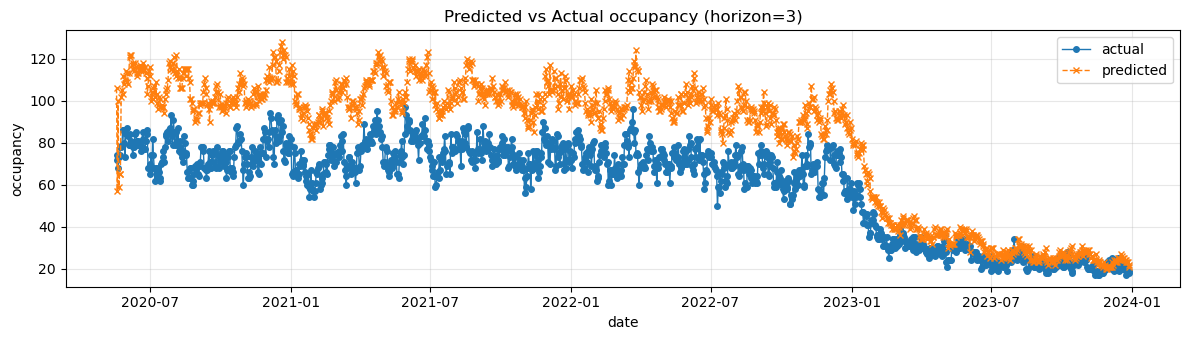

Saved timeseries plots for h=5 to ./metri&figures\timeseries_h5_20200519_20231226.png


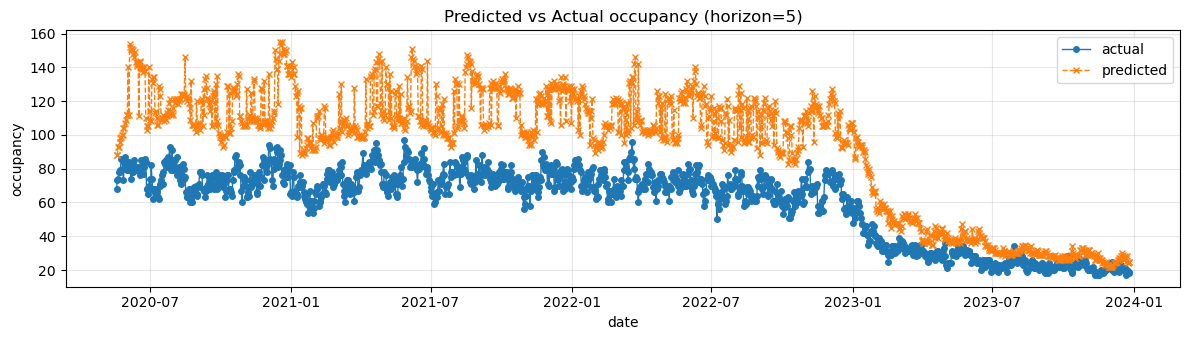

Saved timeseries plots for h=7 to ./metri&figures\timeseries_h7_20200519_20231224.png


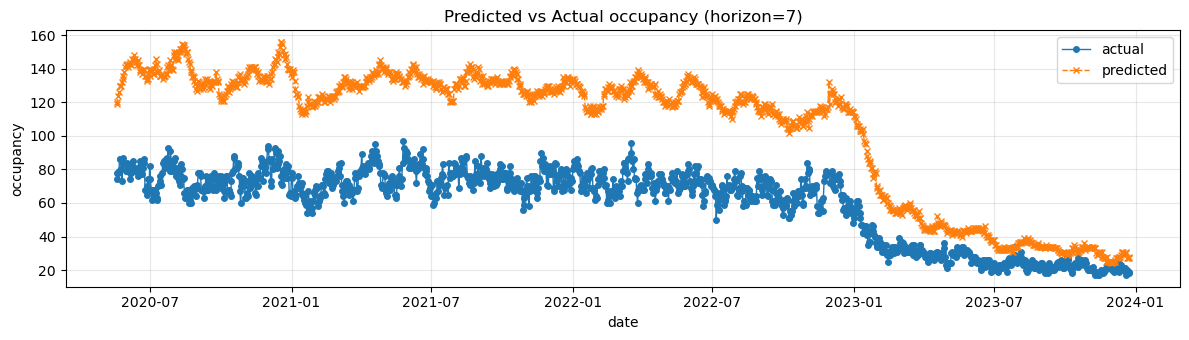

Saved scatter+residual plots for h=3 to ./metri&figures\scatter_resid_h3_20200519_20231224.png


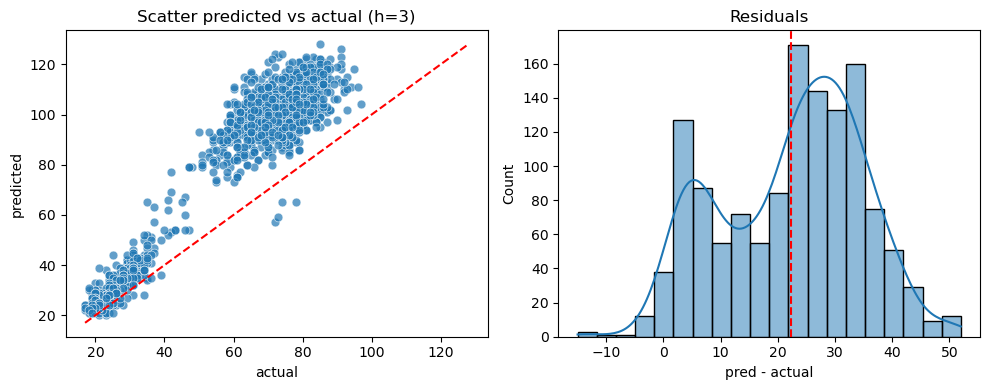

Saved scatter+residual plots for h=5 to ./metri&figures\scatter_resid_h5_20200519_20231224.png


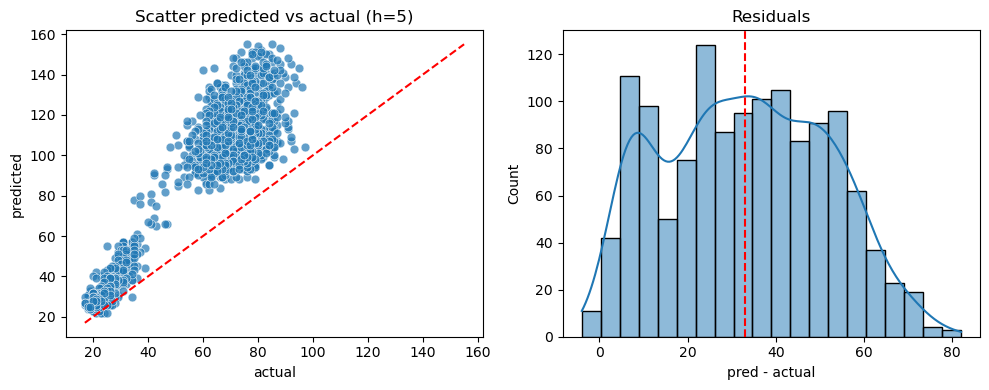

Saved scatter+residual plots for h=7 to ./metri&figures\scatter_resid_h7_20200519_20231224.png


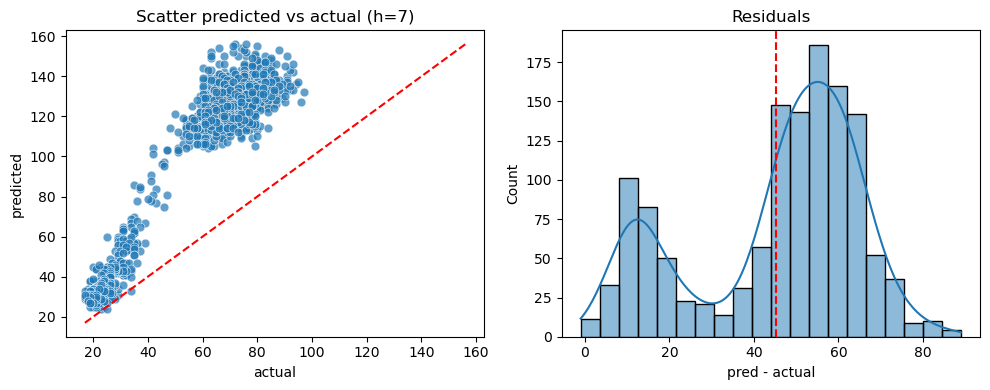

All figures (if generated) are saved under: ./metri&figures


In [8]:
# Metrics and visualizations for predicted occupancy vs actual
import os
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except Exception:
    sns = None

# ensure df_merged and date column exist
df = df_merged.copy()
df['date'] = pd.to_datetime(df['date'])

# directory to save figures
fig_dir = './metri&figures'
os.makedirs(fig_dir, exist_ok=True)

horizons = [3, 5, 7]
metrics = []
for h in horizons:
    pred_col = f'O_{h}'
    actual_col = f'actual_{h}'
    if pred_col not in df.columns or actual_col not in df.columns:
        print(f"Skipping {h} days: missing column {pred_col} or {actual_col}")
        continue
    tmp = df[['date', pred_col, actual_col]].dropna()
    y_pred = tmp[pred_col].astype(float)
    y_true = tmp[actual_col].astype(float)
    mae = np.mean(np.abs(y_pred - y_true))
    mse = np.mean((y_pred - y_true) ** 2)
    rmse = np.sqrt(mse)
    bias = np.mean(y_pred - y_true)
    # MAPE: avoid division by zero by excluding zeros in true values
    with np.errstate(divide='ignore', invalid='ignore'):
        denom = y_true.replace(0, np.nan)
        mape = np.nanmean(np.abs((y_pred - y_true) / denom)) * 100
    metrics.append({'horizon': h, 'n': len(tmp), 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'Bias': bias, 'MAPE_%': mape})

metrics_df = pd.DataFrame(metrics).set_index('horizon')
display(metrics_df)

# save metrics to CSV
out_path = './metri&figures/occupancy_metrics_summary.csv'
metrics_df.to_csv(out_path)
print(f"Saved metrics summary to {out_path}")

# Time-series plots: predicted vs actual (save PNG)
for h in horizons:
    pred_col = f'O_{h}'
    actual_col = f'actual_{h}'
    if pred_col not in df.columns or actual_col not in df.columns:
        continue
    tmp = df[['date', pred_col, actual_col]].dropna().sort_values('date')
    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(tmp['date'], tmp[actual_col], label='actual', marker='o', markersize=4, lw=1)
    ax.plot(tmp['date'], tmp[pred_col], label='predicted', marker='x', markersize=4, lw=1, linestyle='--')
    ax.set_title(f'Predicted vs Actual occupancy (horizon={h})')
    ax.set_xlabel('date')
    ax.set_ylabel('occupancy')
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    # filename using date range to be informative
    try:
        dt0 = tmp['date'].min().strftime('%Y%m%d')
        dt1 = tmp['date'].max().strftime('%Y%m%d')
    except Exception:
        dt0 = 'start'
        dt1 = 'end'
    png_path = os.path.join(fig_dir, f'timeseries_h{h}_{dt0}_{dt1}.png')

    try:
        fig.savefig(png_path, dpi=200)
        
        print(f'Saved timeseries plots for h={h} to {png_path}')
    except Exception as e:
        print('Failed to save timeseries plot for h=', h, e)
    plt.show()
    plt.close(fig)

# Scatter plots + residual histograms (save PNG & SVG)
for h in horizons:
    pred_col = f'O_{h}'
    actual_col = f'actual_{h}'
    if pred_col not in df.columns or actual_col not in df.columns:
        continue
    tmp = df[[pred_col, actual_col]].dropna()
    y_pred = tmp[pred_col]
    y_true = tmp[actual_col]
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    ax = axes[0]
    if sns is not None:
        sns.scatterplot(x=y_true, y=y_pred, s=40, alpha=0.7, ax=ax)
    else:
        ax.scatter(y_true, y_pred, s=20, alpha=0.7)
    ax.plot([mn, mx], [mn, mx], color='red', linestyle='--')
    ax.set_xlabel('actual')
    ax.set_ylabel('predicted')
    ax.set_title(f'Scatter predicted vs actual (h={h})')

    ax2 = axes[1]
    resid = (y_pred - y_true)
    if sns is not None:
        sns.histplot(resid, kde=True, bins=20, ax=ax2)
    else:
        ax2.hist(resid, bins=20, alpha=0.7)
    ax2.axvline(resid.mean(), color='red', linestyle='--')
    ax2.set_title('Residuals')
    ax2.set_xlabel('pred - actual')

    fig.tight_layout()
    png_path = os.path.join(fig_dir, f'scatter_resid_h{h}_{dt0}_{dt1}.png')
    try:
        fig.savefig(png_path, dpi=200)
    
        print(f'Saved scatter+residual plots for h={h} to {png_path}')
    except Exception as e:
        print('Failed to save scatter/resid plot for h=', h, e)
    plt.show()
    plt.close(fig)

print(f"All figures (if generated) are saved under: {fig_dir}")


# Occupancy Change

In [9]:
import re
import numpy as np

# ensure date is datetime and work with a datetime-indexed view
df_merged['date'] = pd.to_datetime(df_merged['date'])
df_idx = df_merged.set_index('date')

for col in [c for c in df_merged.columns if c != 'date']:
    m = re.search(r'_(\d+)$', col)
    if not m:
        # no numeric horizon suffix -> cannot compute date+offset; fill with NaN
        df_merged[f'delta_{col}'] = np.nan
        continue
    offset = int(m.group(1))
    s = pd.to_numeric(df_idx[col], errors='coerce')
    shifted = s.reindex(s.index + pd.Timedelta(days=offset))
    # result aligned to original index order
    df_merged[f'delta_{col}'] = (shifted.values - s.values)

# only keep date and delta_* columns
delta_cols = [c for c in df_merged.columns if c.startswith('delta_')]
df_merged = df_merged[['date'] + delta_cols]
# preview
df_merged.head()

,date,delta_O_3,delta_actual_3,delta_O_5,delta_actual_5,delta_O_7,delta_actual_7
0,2020-05-19,-47.0,-1.0,8.0,11.0,13.0,-1.0
1,2020-05-20,8.0,2.0,11.0,13.0,14.0,6.0
2,2020-05-21,-35.0,10.0,7.0,12.0,12.0,9.0
3,2020-05-22,43.0,5.0,7.0,2.0,12.0,5.0
4,2020-05-23,40.0,5.0,6.0,-5.0,11.0,-3.0


,n,MAE,MSE,RMSE,Bias
horizon,,,,,
3,1316,7.230243,91.607143,9.571162,-0.029635
5,1312,10.891006,213.523628,14.612448,-0.040396
7,1308,7.275994,88.808104,9.423805,-0.191896


Saved occupancy change metrics summary to ./metri&figures/occupancy_change_metrics_summary.csv
Saved timeseries change plots for h=3 to ./metri&figures\timeseries_change_h3_20200519_20231225.png


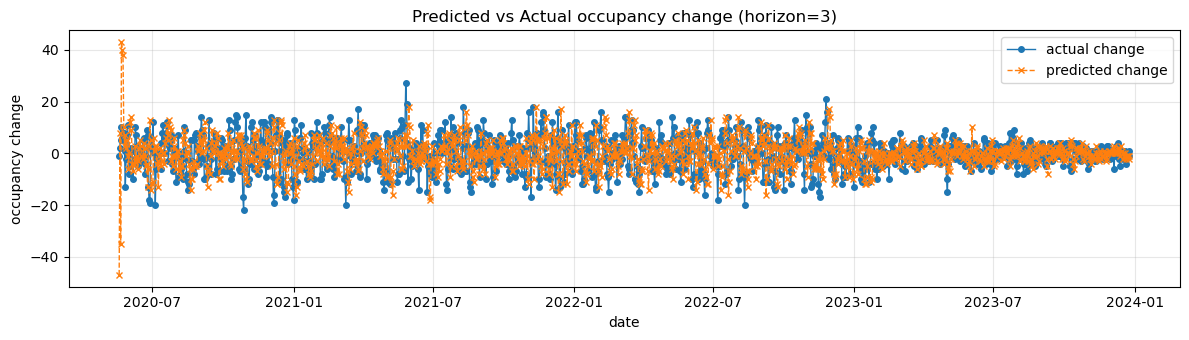

Saved timeseries change plots for h=5 to ./metri&figures\timeseries_change_h5_20200519_20231221.png


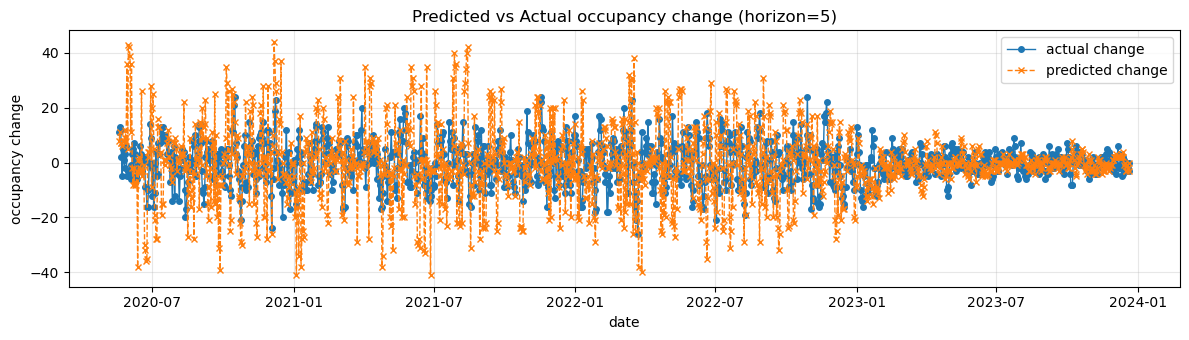

Saved timeseries change plots for h=7 to ./metri&figures\timeseries_change_h7_20200519_20231217.png


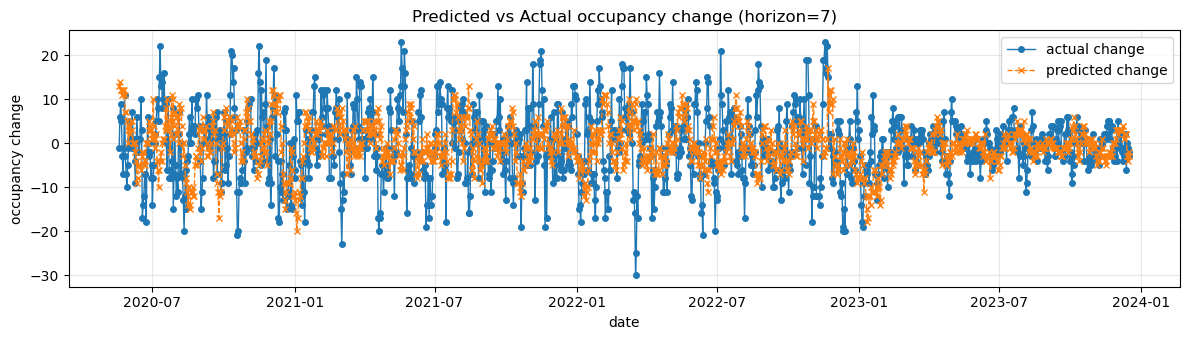

Saved scatter+residual change plots for h=3 to ./metri&figures\scatter_resid_change_h3_20200519_20231217.png


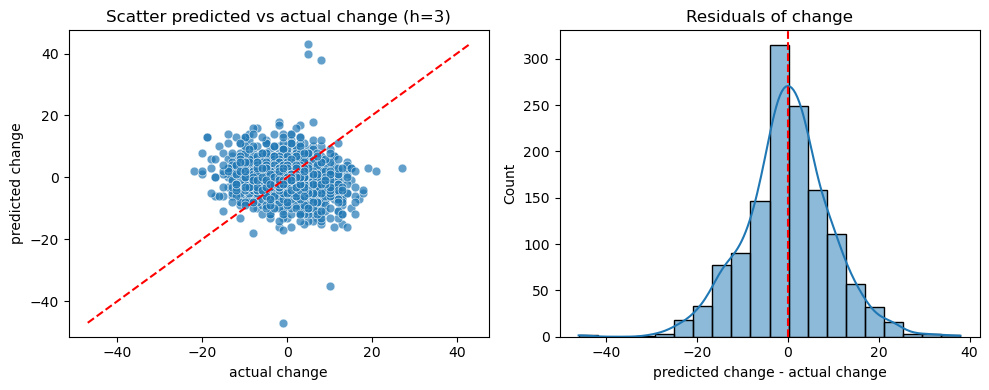

Saved scatter+residual change plots for h=5 to ./metri&figures\scatter_resid_change_h5_20200519_20231217.png


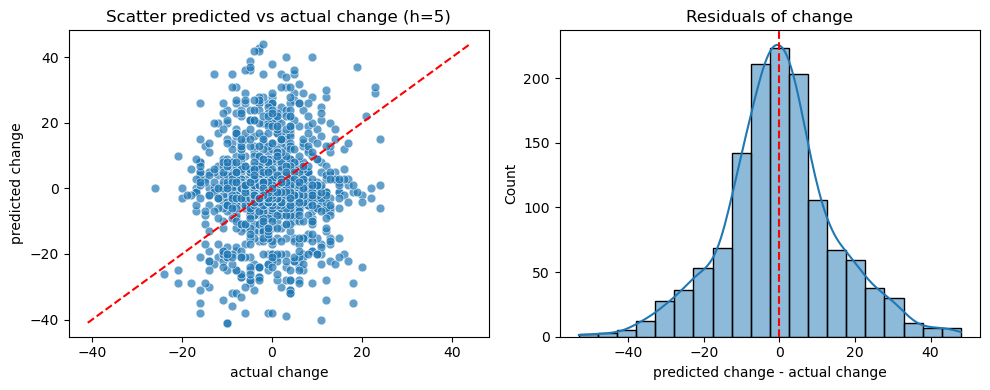

Saved scatter+residual change plots for h=7 to ./metri&figures\scatter_resid_change_h7_20200519_20231217.png


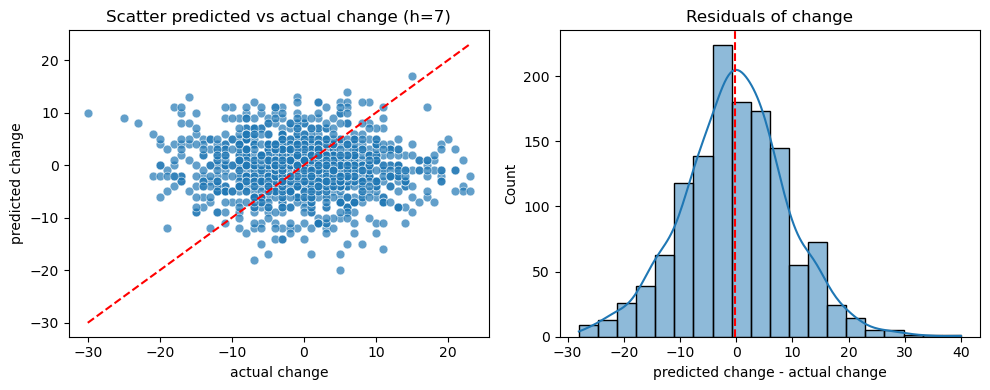

In [10]:
# Metrics and visualizations for predicted occupancy change vs actual change

# ensure df_merged and date column exist
df = df_merged.copy()
df['date'] = pd.to_datetime(df['date'])
# directory to save figures
fig_dir = './metri&figures'
os.makedirs(fig_dir, exist_ok=True)
horizons = [3, 5, 7]
metrics = []

for h in horizons:
    pred_col = f'delta_O_{h}'
    actual_col = f'delta_actual_{h}'
    if pred_col not in df.columns or actual_col not in df.columns:
        print(f"Skipping {h} days: missing column {pred_col} or {actual_col}")
        continue
    tmp = df[['date', pred_col, actual_col]].dropna()
    y_pred = tmp[pred_col].astype(float)
    y_true = tmp[actual_col].astype(float)
    mae = np.mean(np.abs(y_pred - y_true))
    mse = np.mean((y_pred - y_true) ** 2)
    rmse = np.sqrt(mse)
    bias = np.mean(y_pred - y_true)
    metrics.append({'horizon': h, 'n': len(tmp), 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'Bias': bias})
metrics_df = pd.DataFrame(metrics).set_index('horizon')
display(metrics_df)
# save metrics to CSV
out_path = './metri&figures/occupancy_change_metrics_summary.csv'
metrics_df.to_csv(out_path)
print(f"Saved occupancy change metrics summary to {out_path}")

# Time-series plots: predicted occupancy change vs actual (save PNG)
for h in horizons:
    pred_col = f'delta_O_{h}'
    actual_col = f'delta_actual_{h}'
    if pred_col not in df.columns or actual_col not in df.columns:
        continue
    tmp = df[['date', pred_col, actual_col]].dropna().sort_values('date')
    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(tmp['date'], tmp[actual_col], label='actual change', marker='o', markersize=4, lw=1)
    ax.plot(tmp['date'], tmp[pred_col], label='predicted change', marker='x', markersize=4, lw=1, linestyle='--')
    ax.set_title(f'Predicted vs Actual occupancy change (horizon={h})')
    ax.set_xlabel('date')
    ax.set_ylabel('occupancy change')
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    # filename using date range to be informative
    try:
        dt0 = tmp['date'].min().strftime('%Y%m%d')
        dt1 = tmp['date'].max().strftime('%Y%m%d')
    except Exception:
        dt0 = 'start'
        dt1 = 'end'
    png_path = os.path.join(fig_dir, f'timeseries_change_h{h}_{dt0}_{dt1}.png')

    try:
        fig.savefig(png_path, dpi=200)
        print(f'Saved timeseries change plots for h={h} to {png_path}')
    except Exception as e:
        print('Failed to save timeseries change plot for h=', h, e)
    plt.show()
    plt.close(fig)

    


# Scatter plots + residual histograms for occupancy change (save PNG)
for h in horizons:
    pred_col = f'delta_O_{h}'
    actual_col = f'delta_actual_{h}'
    if pred_col not in df.columns or actual_col not in df.columns:
        continue
    tmp = df[[pred_col, actual_col]].dropna()
    y_pred = tmp[pred_col]
    y_true = tmp[actual_col]
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    ax = axes[0]
    if sns is not None:
        sns.scatterplot(x=y_true, y=y_pred, s=40, alpha=0.7, ax=ax)
    else:
        ax.scatter(y_true, y_pred, s=20, alpha=0.7)
    ax.plot([mn, mx], [mn, mx], color='red', linestyle='--')
    ax.set_xlabel('actual change')
    ax.set_ylabel('predicted change')
    ax.set_title(f'Scatter predicted vs actual change (h={h})')

    ax2 = axes[1]
    resid = (y_pred - y_true)
    if sns is not None:
        sns.histplot(resid, kde=True, bins=20, ax=ax2)
    else:
        ax2.hist(resid, bins=20, alpha=0.7)
    ax2.axvline(resid.mean(), color='red', linestyle='--')
    ax2.set_title('Residuals of change')
    ax2.set_xlabel('predicted change - actual change')
    fig.tight_layout()
    png_path = os.path.join(fig_dir, f'scatter_resid_change_h{h}_{dt0}_{dt1}.png')
    try:
        fig.savefig(png_path, dpi=200)
        print(f'Saved scatter+residual change plots for h={h} to {png_path}')
    except Exception as e:
        print('Failed to save scatter/resid change plot for h=', h, e)
    plt.show()
    plt.close(fig)